In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение функции argrelextrema
# из пакета scipy.signal,
# возвращающей значения абсцисс
# локальных экстремумов сигнала
from scipy.signal import argrelextrema

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения потенциала, в котором
# двигается частица
def U(x, X_Min, X_Max):
    if (x >= X_Min) and (x <= X_Max):
        z = -1
    else:
        z = 10**309
    return z

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# численные решения уравнения Шредингера
# для заданного значения энергии частицы,
# вычисляемые его интегрированием
# слева на право (массив Psi_Left2Rigth);
# справа налево (массив Psi_Rigth2Left)
# среднеквадратическое отклонение разности
# массивов Psi_Left2Rigth, Psi_Rigth2Left;
# значение критерия гладкости сшивки решений
# уравнения Шредингера (16.19)
def Num_Shred(Gamma, E, V, X_min, X_max, N_Greed):
    # Gamma - коэффициент, входящий
    #         в безразмерное уравнение Шредингера (16.23)
    # E - значение энергии частицы
    # V - значения потенциала U(x), вычисленные
    #     вс узлах координатной сетки
    # X_min - левая граница координатной сетки
    # X_max - правая граница координатной стеки
    # N_Greed - число узорв коордиантной стеки

    # вычисление шага координатной сетки
    dx = (X_max - X_min) / (N_Greed - 1)
    # вычисление значения константы с
    c = dx**2 * Gamma**2 / 12

    # инициализация массива, используемого
    # для вычисление решения уравнения Шредингера
    # численным интегрированием слева направо
    Psi_Left2Rigth = np.zeros(N_Greed)

    # вычисление решения уравнения Шредингера
    # численным интегрированием слева направо
    Psi_Left2Rigth[0] = 0
    Psi_Left2Rigth[1] = 9.9999 * 10**-10
    K_Im1 = c * (E - V[0])
    K_i = c * (E - V[1])
    for i in range(1, N_Greed - 1):
        K_Ip1 = c * (E - V[i + 1])
        if (K_i * K_Ip1 <= 0) and (K_i > 0):
            I_Match = i
            i = N_Greed - 1
        if i <= N_Greed - 1:
            Psi_Left2Rigth[i + 1] = (
                Psi_Left2Rigth[i] * (2 - 10 * K_i) - Psi_Left2Rigth[i - 1] * (1 + K_Im1)
            ) / (1 + K_Ip1)
            if np.abs(Psi_Left2Rigth[i + 1]) >= 10**10:
                for k in range(i):
                    Psi_Left2Rigth[k] = Psi_Left2Rigth[k] * 9.99999 * 10**-6
                K_Im1 = K_i
                K_i = K_Ip1

    # инициализация массива, используемого
    # для вычисление решения уравнения Шредингера
    # численным интегрированием cправа налево
    Psi_Rigth2Left = np.zeros(N_Greed)

    # вычисление решения уравнения Шредингера
    # численным интегрированием справа налево
    Psi_Rigth2Left[N_Greed - 1] = 0
    Psi_Rigth2Left[N_Greed - 2] = 9.99999 * 10**-10
    K_Ip1 = c * (E - V[N_Greed - 1])
    K_i = c * (E - V[N_Greed - 2])
    for i in range(N_Greed - 2, 0, -1):
        K_Im1 = c * (E - V[i - 1])
        Psi_Rigth2Left[i - 1] = (
            Psi_Rigth2Left[i] * (2 - 10 * K_i) - Psi_Rigth2Left[i + 1] * (1 + K_Ip1)
        ) / (1 + K_Im1)
        if np.abs(Psi_Rigth2Left[i]) > 10**10:
            for k in range(N_Greed - 1, i, -1):
                Psi_Rigth2Left[k] = Psi_Rigth2Left[k] * 9.99999 * 10**-6
        K_Ip1 = K_i
        K_i = K_Im1

    # нормировка вычисленных численных
    # решений уравнения Шредингера
    Norm_Left2Rigth = np.sum(Psi_Left2Rigth**2) * dx
    Psi_Left2Rigth = Psi_Left2Rigth / np.sqrt(Norm_Left2Rigth)

    Norm_Rigth2Left = np.sum(Psi_Rigth2Left**2) * dx
    Psi_Rigth2Left = Psi_Rigth2Left / np.sqrt(Norm_Rigth2Left)

    # задание номера точки, в которой
    # значение критерия гладкости
    # численных решений уравнения Шредингера
    I_Match = N_Greed - 10

    # проверка одинаковости знаков
    # значений Psi_Left2Rigth[I_Match], Psi_Rigth2Left[I_Match]
    if Psi_Left2Rigth[I_Match] * Psi_Rigth2Left[I_Match] < 0:
        # если знаки различны умножение
        # элементов массива Psi_Rigth2Left[I_Match] на -1
        Psi_Rigth2Left = -Psi_Rigth2Left

    # вычисление среднеквадратического
    # отклонения разности численных решений \
    # уравнения Шредингера, вычисленных
    # интегрированием слева на право и
    # справа налево
    Diff_Psi = np.sqrt(np.sum((Psi_Left2Rigth - Psi_Rigth2Left) ** 2)) * dx

    # вычисление значения критерия гладкости
    # численных решений уравнения Шредингера
    F = (
        Psi_Left2Rigth[I_Match]
        + Psi_Rigth2Left[I_Match]
        - (Psi_Left2Rigth[I_Match - 1] + Psi_Rigth2Left[I_Match + 1])
    )

    return Psi_Left2Rigth, Psi_Rigth2Left, Diff_Psi, F

In [ ]:
# Ячейка № 4

# задание значения координаты
# левой границы координатной сетки
X_Min = -0.5

# задание значения координаты
# правой границы координатной сетки
X_Max = 0.5

# задание значения
# коэффициента Gamma в (16.23)
Gamma = 20

# задание граничных значений
# диапазона изменения
# энергии частицы
E_max = 0
E_min = -1

# задание числа узлов координатной сетки
N_Greed = 1000

# инициализация массива, используемого
# хранения коордианат узлов используемой сетки
X = np.zeros(N_Greed)

# инициализация массива, используемого
# хранения значений потенциала,
# вычисляемого в узлах координатной сетки
V = np.zeros(N_Greed)

# вычисление шага координатной сетки
dx = (X_Max - X_Min) / (N_Greed - 1)

# вычисление координат узлов
# используемой сетки и
# соответствующих значений потенциала
for i in range(N_Greed):
    X[i] = X_Min + dx * i
    V[i] = U(X[i], X_Min, X_Max)

# вычисление элементов массива, содержащего
# значения энергии частицы
E = np.linspace(E_min, E_max, 10**3)

# инициализация массивов, используемых для
# хранения значений среднеквадратического
# значений разности массивов Psi_Left2Rigth, Psi_Rigth2Left
# и значений критерия гладкости
# численных решений уравнения Шредингера, соответственно
d_Psi = np.zeros(len(E))
F = np.zeros(len(E))

# инициализация массивов, используемых для
# хранения численных решений уравнения Шредингера,
# вычисленных интегрированием
# слева направо и справа налево,  соответственно
Psi_L2R = np.zeros([len(E), N_Greed])
Psi_R2L = np.zeros([len(E), N_Greed])

# вычисление численных решений уравнения Шредингера,
# среднеквадратического отклонения их разностей
# и критерия гладкости решений
for i in range(len(E)):
    [Psi_L2R[i, :], Psi_R2L[i, :], d_Psi[i], F[i]] = Num_Shred(
        Gamma, E[i], V, X_Min, X_Max, N_Greed
    )


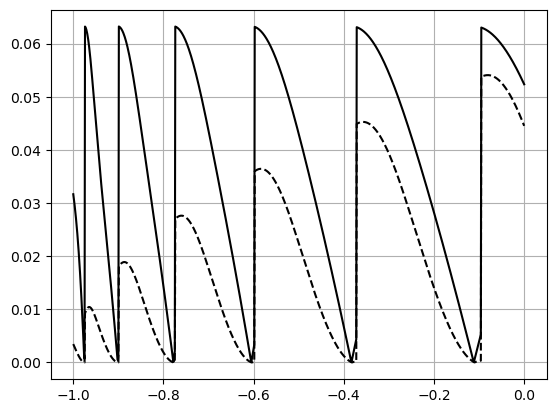

In [5]:
# Ячейка № 5

# визуализация массивов d_Psi, F

# визуализация зависимости
# среднеквадратического отклонения
# разностей численных решений уравнения Шредингера,
# вычисленных численным интегрированием
# слева направо и справа налево,
# от энергии частицы
plt.plot(E, d_Psi, "-k")

# визуализация зависимости
# модуля критерия гладкости
# от энергии частицы
plt.plot(E, abs(F), "--k")

plt.grid(True)

In [6]:
# Ячейка № 6

# вычисление абсцисс локальных минимумов
# массива d_Psi
min_d_Psi = argrelextrema(d_Psi, np.less)

# отображение значений энергии частицы,
# соответствующих номерам,
# сохраненных в массиве min_d_Psi
print(
    "Оценки энергий частицы по разности массивов Psi_L2R, Psi_R2L: ",
    "\n",
    E[min_d_Psi],
    "\n",
)

# вычисление абсцисс локальных минимумов
# абсолютных значений массива F
min_F = argrelextrema(np.abs(F), np.less)

# отображение значений энергии частицы,
# соответствующих номерам,
# сохраненных в массиве min_F
print("Оценки энергий частицы по критерию гладкости решения F: ", "\n", E[min_F], "\n")

Оценки энергий частицы по разности массивов Psi_L2R, Psi_R2L:  
 [-0.97497497 -0.9009009  -0.77777778 -0.60560561 -0.38338338 -0.11211211] 

Оценки энергий частицы по критерию гладкости решения F:  
 [-0.97497497 -0.9009009  -0.77777778 -0.6046046  -0.38238238 -0.11011011] 



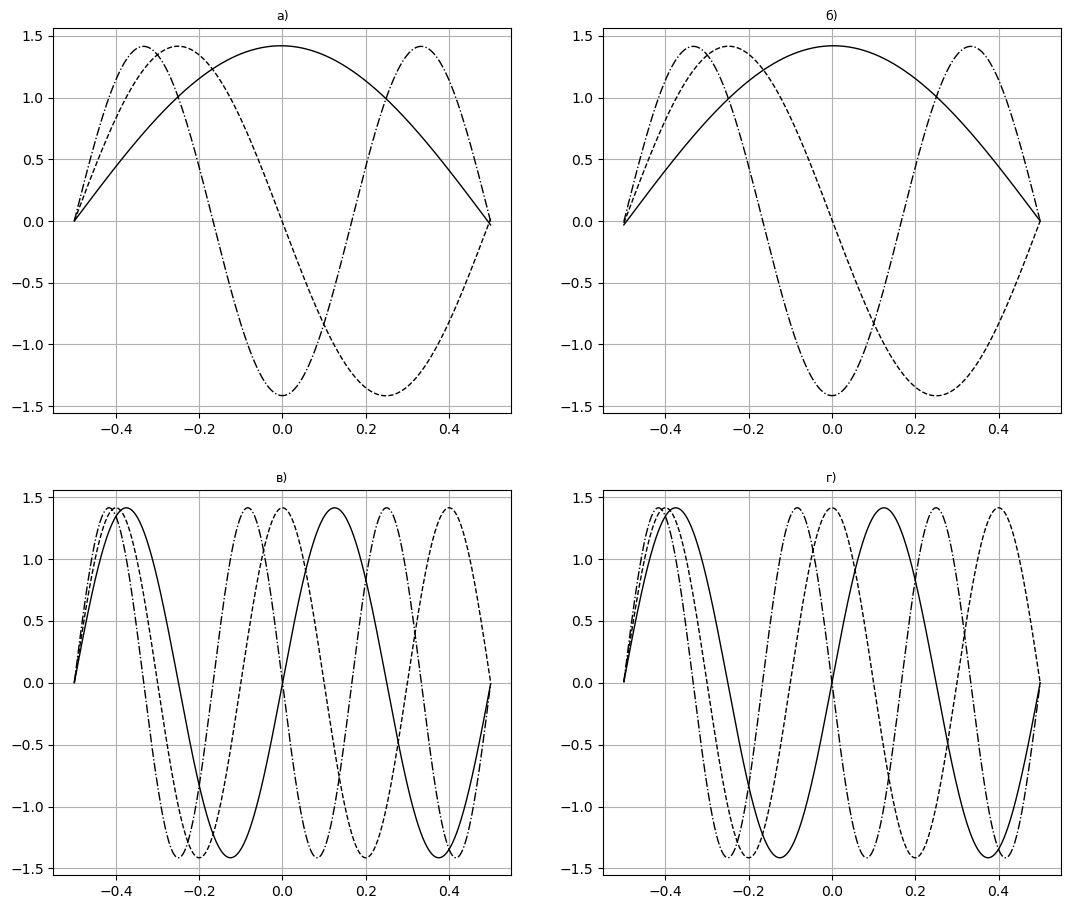

In [7]:
# Ячейка № 7

# визуализация численных решений уравнения Шредингера
fig = plt.figure(figsize=(13, 11))

# визуализация решения
# уравнения Шредингера, вычисленного
# численным интегрированием слева направо,
# для следующих значений энергии частицы:
# -0.97497497; -0.9009009;  -0.77777778
ax = plt.subplot(2, 2, 1)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][0], :], "-k", lw=1)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][1], :], "--k", lw=1)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][2], :], "-.k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация решения
# уравнения Шредингера, вычисленного
# численным интегрированием справа налево,
# для следующих значений энергии частицы:
# -0.60560561; -0.38338338; -0.11211211
ax = plt.subplot(2, 2, 3)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][3], :], "-k", lw=1)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][4], :], "--k", lw=1)
plt.plot(X[:], Psi_L2R[min_d_Psi[0][5], :], "-.k", lw=1)
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация решения
# уравнения Шредингера, вычисленного
# численным интегрированием справа налево,
# для следующих значений энергии частицы:
# -0.97497497; -0.9009009;  -0.77777778
ax = plt.subplot(2, 2, 2)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][0], :], "-k", lw=1)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][1], :], "--k", lw=1)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][2], :], "-.k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация решения
# уравнения Шредингера, вычисленного
# численным интегрированием справа налево,
# для следующих значений энергии частицы:
# -0.6046046;  -0.38238238; -0.11011011
ax = plt.subplot(2, 2, 4)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][3], :], "-k", lw=1)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][4], :], "--k", lw=1)
plt.plot(X[:], Psi_R2L[min_d_Psi[0][5], :], "-.k", lw=1)
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()